# Насколько человек токсичен в переписке

Мини-проект: анализ Telegram-переписки, ручная разметка токсичности, обучение бинарных классификаторов и временная динамика токсичности.

В notebook не используются реальные имена участников. `from_id` заменяется на стабильные значения вида `user_001`, ссылки и контакты заменяются токенами.


## 1. Импорты и настройки



In [46]:
from __future__ import annotations

import json
import os
import re
import warnings
from datetime import datetime
from hashlib import sha256
from pathlib import Path

ROOT = Path(".").resolve()
OUTPUT_DIR = ROOT / "data"
MPLCONFIGDIR = OUTPUT_DIR / ".matplotlib"
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))
os.environ.setdefault("MPLBACKEND", "Agg")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

DATA_FILES = [ROOT / "kpp.json", ROOT / "ls.json"]
LABELING_SAMPLE_PATH = OUTPUT_DIR / "labeling_sample.csv"
LABELED_MESSAGES_PATH = OUTPUT_DIR / "labeled_messages.csv"

RANDOM_STATE = 42
LABELING_SAMPLE_SIZE = 10000
# Поставьте None, если хотите прогнать notebook по всем сообщениям.
# По умолчанию берём 80000 сообщений, чтобы notebook быстрее пересчитывался.
MAX_MESSAGES_FOR_NOTEBOOK = 200000

# Если вы размечаете не 0/1, а score, создайте колонку toxic_score или toxicity_score.
# При SCORE_TO_BINARY_THRESHOLD=None порог выбирается автоматически:
# 0.5 для шкалы 0..1, 5 для шкалы 0..10, 50 для шкалы 0..100.
SCORE_TO_BINARY_THRESHOLD = None

# Если ручной разметки нет, notebook сам создаст слабые метки по плохим словам
# и risk_score. Это позволяет сразу проверить модель.
AUTO_LABEL_WITH_RULES = True


## 2. Загрузка, нормализация и анонимизация

Telegram экспортирует `text` двумя способами: строкой или массивом строк/объектов. Функция ниже приводит оба варианта к обычной строке.


In [47]:
PROFANITY_PATTERNS = [
    r"\bбля\w*", r"\bсука\w*", r"\bхуй\w*", r"\bхуя\w*", r"\bхуе\w*",
    r"\bпизд\w*", r"\bеба\w*", r"\bеби\w*", r"\bебл\w*", r"\bёба\w*",
    r"\bёби\w*", r"\bёб\w*", r"\bмуд\w*", r"\bдолбо\w*", r"\bгандон\w*",
]
HOSTILE_PATTERNS = [
    r"\bидиот\w*", r"\bтуп\w*", r"\bдебил\w*", r"\bурод\w*",
    r"\bзаткнись\b", r"\bненавиж\w*", r"\bсдох\w*", r"\bубью\b",
]

PROFANITY_RE = re.compile("|".join(PROFANITY_PATTERNS), flags=re.IGNORECASE)
HOSTILE_RE = re.compile("|".join(HOSTILE_PATTERNS), flags=re.IGNORECASE)
URL_RE = re.compile(r"https?://\S+|www\.\S+", flags=re.IGNORECASE)
EMAIL_RE = re.compile(r"\b[\w.+-]+@[\w-]+\.[\w.-]+\b", flags=re.IGNORECASE)
MENTION_RE = re.compile(r"(?<!\w)@[\w_]{3,}")
PHONE_RE = re.compile(r"(?<!\d)(?:\+?\d[\d\s().-]{7,}\d)(?!\d)")
WHITESPACE_RE = re.compile(r"\s+")

def telegram_text_to_str(value: object) -> str:
    if isinstance(value, str):
        return value
    if isinstance(value, list):
        parts = []
        for item in value:
            if isinstance(item, str):
                parts.append(item)
            elif isinstance(item, dict):
                parts.append(str(item.get("text", "")))
        return "".join(parts)
    return ""

def anonymize_text(text: str) -> str:
    text = URL_RE.sub("<URL>", text)
    text = EMAIL_RE.sub("<EMAIL>", text)
    text = PHONE_RE.sub("<PHONE>", text)
    text = MENTION_RE.sub("<MENTION>", text)
    return WHITESPACE_RE.sub(" ", text).strip()

def stable_hash(*parts: object) -> str:
    payload = "|".join(str(part) for part in parts)
    return sha256(payload.encode("utf-8")).hexdigest()[:16]

def parse_date(value: str | None) -> datetime | pd.NaT:
    if not value:
        return pd.NaT
    try:
        return datetime.fromisoformat(value)
    except ValueError:
        return pd.NaT


In [48]:
def load_telegram_export(path: Path) -> pd.DataFrame:
    with path.open("r", encoding="utf-8") as file:
        payload = json.load(file)

    rows = []
    for message in payload.get("messages", []):
        if message.get("type") != "message":
            continue

        text = anonymize_text(telegram_text_to_str(message.get("text", "")))
        if not text:
            continue

        date = parse_date(message.get("date"))
        from_id = str(message.get("from_id") or "unknown")
        rows.append(
            {
                "message_hash": stable_hash(path.name, message.get("id"), from_id, text),
                "chat": path.stem,
                "date": date,
                "date_unixtime": message.get("date_unixtime"),
                "raw_user_id": from_id,
                "text": text,
            }
        )

    return pd.DataFrame(rows)

frames = []
for data_file in DATA_FILES:
    if not data_file.exists():
        raise FileNotFoundError(f"Файл не найден: {data_file}")
    frames.append(load_telegram_export(data_file))

messages_full = pd.concat(frames, ignore_index=True)

user_map = {
    raw_user_id: f"user_{index:03d}"
    for index, raw_user_id in enumerate(sorted(messages_full["raw_user_id"].unique()), start=1)
}
messages_full["user"] = messages_full["raw_user_id"].map(user_map)
messages_full = messages_full.drop(columns=["raw_user_id"])

messages_full["hour"] = messages_full["date"].dt.hour
messages_full["month"] = messages_full["date"].dt.to_period("M").astype(str)

if MAX_MESSAGES_FOR_NOTEBOOK is not None and len(messages_full) > MAX_MESSAGES_FOR_NOTEBOOK:
    messages = messages_full.sample(n=MAX_MESSAGES_FOR_NOTEBOOK, random_state=RANDOM_STATE).copy()
else:
    messages = messages_full.copy()

messages.shape


(200000, 8)

In [49]:
summary = pd.DataFrame(
    {
        "metric": [
            "messages_used_in_notebook",
            "messages_after_filtering_full",
            "anonymous_users",
            "date_min",
            "date_max",
            "chats",
        ],
        "value": [
            len(messages),
            len(messages_full),
            messages["user"].nunique(),
            messages["date"].min(),
            messages["date"].max(),
            ", ".join(sorted(messages["chat"].unique())),
        ],
    }
)
summary


,metric,value
0,messages_used_in_notebook,200000
1,messages_after_filtering_full,381812
2,anonymous_users,4
3,date_min,2023-09-13 23:02:35
4,date_max,2026-05-06 19:50:25
5,chats,"kpp, ls"


## 3. Фичи

Кроме TF-IDF добавляем числовые признаки: длина сообщения, количество слов, частота мата, пунктуация и caps ratio.


In [50]:
def caps_ratio(text: str) -> float:
    letters = [ch for ch in text if ch.isalpha()]
    if not letters:
        return 0.0
    return sum(ch.isupper() for ch in letters) / len(letters)

def add_numeric_features(df: pd.DataFrame) -> pd.DataFrame:
    result = df.copy()
    result["char_len"] = result["text"].str.len()
    result["word_count"] = result["text"].str.count(r"\w+")
    result["profanity_count"] = result["text"].apply(lambda x: len(PROFANITY_RE.findall(x)))
    result["hostile_count"] = result["text"].apply(lambda x: len(HOSTILE_RE.findall(x)))
    result["exclamation_count"] = result["text"].str.count("!")
    result["question_count"] = result["text"].str.count(r"\?")
    result["caps_ratio"] = result["text"].apply(caps_ratio)
    result["risk_score"] = (
        result["profanity_count"] * 3.0
        + result["hostile_count"] * 2.0
        + result["exclamation_count"].clip(upper=5) * 0.4
        + result["question_count"].clip(upper=5) * 0.2
        + (result["caps_ratio"] * 3.0).clip(upper=2.0)
    )
    return result

messages = add_numeric_features(messages)

feature_summary = messages[
    ["char_len", "word_count", "profanity_count", "hostile_count", "exclamation_count", "question_count", "caps_ratio"]
].describe().T
feature_summary


,count,mean,std,min,25%,50%,75%,max
char_len,200000.0,20.097090,83.730910,1.0,7.0,14.000000,23.000000,4095.0
word_count,200000.0,3.751905,11.490007,0.0,1.0,3.000000,4.000000,1024.0
profanity_count,200000.0,0.101790,0.314626,0.0,0.0,0.000000,0.000000,7.0
hostile_count,200000.0,0.002440,0.059532,0.0,0.0,0.000000,0.000000,15.0
exclamation_count,200000.0,0.004010,0.113903,0.0,0.0,0.000000,0.000000,16.0
question_count,200000.0,0.077085,1.279000,0.0,0.0,0.000000,0.000000,370.0
caps_ratio,200000.0,0.079938,0.163064,0.0,0.0,0.016667,0.090909,1.0


## 4. CSV для ручной разметки

Выборка смешанная: часть сообщений берётся случайно, часть - из кандидатов с повышенным `risk_score`. Это помогает получить достаточно токсичных примеров для обучения.

Заполните колонку `toxic`:

- `1` - оскорбление, унижение, агрессия, угроза, токсичный мат в адрес человека/группы;
- `0` - нейтральное сообщение, обычная эмоциональная речь, мат без атаки на человека.


In [51]:
def build_labeling_sample(df: pd.DataFrame, sample_size: int = LABELING_SAMPLE_SIZE) -> pd.DataFrame:
    risky = df[df["risk_score"] > 0]
    risky_n = min(len(risky), sample_size // 2)
    risky_sample = risky.sample(n=risky_n, random_state=RANDOM_STATE) if risky_n else risky

    remaining = df.drop(index=risky_sample.index)
    random_n = min(sample_size - len(risky_sample), len(remaining))
    random_sample = remaining.sample(n=random_n, random_state=RANDOM_STATE) if random_n else remaining

    sample = pd.concat(
        [
            risky_sample.assign(selection_reason="risk_candidate"),
            random_sample.assign(selection_reason="random"),
        ],
        ignore_index=True,
    ).sample(frac=1, random_state=RANDOM_STATE)

    sample = sample.reset_index(drop=True)
    sample.insert(0, "label_id", np.arange(1, len(sample) + 1))
    sample["toxic"] = ""
    sample["notes"] = ""

    return sample[
        [
            "label_id",
            "message_hash",
            "date",
            "hour",
            "month",
            "chat",
            "user",
            "text",
            "toxic",
            "notes",
            "selection_reason",
            "risk_score",
            "char_len",
            "word_count",
            "profanity_count",
            "hostile_count",
            "exclamation_count",
            "question_count",
            "caps_ratio",
        ]
    ]

OUTPUT_DIR.mkdir(exist_ok=True)
if LABELING_SAMPLE_PATH.exists():
    existing_labeling_sample = pd.read_csv(LABELING_SAMPLE_PATH)
else:
    existing_labeling_sample = None

if existing_labeling_sample is None or len(existing_labeling_sample) < LABELING_SAMPLE_SIZE:
    labeling_sample = build_labeling_sample(messages)
    labeling_sample.to_csv(LABELING_SAMPLE_PATH, index=False, encoding="utf-8-sig")
    if existing_labeling_sample is None:
        print(f"Создан файл для разметки: {LABELING_SAMPLE_PATH}")
    else:
        print(
            f"Файл был меньше нужного размера "
            f"({len(existing_labeling_sample)} < {LABELING_SAMPLE_SIZE}) и пересоздан: {LABELING_SAMPLE_PATH}"
        )
else:
    labeling_sample = existing_labeling_sample
    print(f"Файл уже существует: {LABELING_SAMPLE_PATH} ({len(labeling_sample)} строк)")

labeling_sample.drop(columns=["text"]).head()


Создан файл для разметки: C:\Users\gosha\work\proj_nik\data\labeling_sample.csv


,label_id,message_hash,date,hour,month,chat,user,toxic,notes,selection_reason,risk_score,char_len,word_count,profanity_count,hostile_count,exclamation_count,question_count,caps_ratio
0,1,200a661cdb0dc4e6,2024-11-29 14:44:31,14,2024-11,kpp,user_001,,,random,0.176471,19,3,0,0,0,0,0.058824
1,2,48dd1dfa1a382dac,2026-01-19 23:53:45,23,2026-01,kpp,user_001,,,risk_candidate,0.375000,8,1,0,0,0,0,0.125000
2,3,b4229878b56ca715,2025-09-28 21:10:59,21,2025-09,kpp,user_001,,,risk_candidate,0.285714,42,7,0,0,0,1,0.028571
3,4,64c0a0d5642cae4b,2024-01-16 20:14:04,20,2024-01,kpp,user_002,,,risk_candidate,3.000000,4,1,1,0,0,0,0.000000
4,5,12bef16db423e293,2024-01-18 19:53:18,19,2024-01,kpp,user_002,,,risk_candidate,0.200000,11,2,0,0,0,1,0.000000


## 5. Загрузка ручной разметки

После разметки сохраните файл как `data/labeled_messages.csv`. Если вы разметили прямо `data/labeling_sample.csv`, notebook тоже сможет его прочитать.

Поддерживаются два варианта:

- бинарная колонка `toxic`: `0` или `1`;
- score-колонка `toxic_score` или `toxicity_score`: notebook сам превратит score в `toxic` по порогу.

Если ручной разметки нет, notebook автоматически создаст слабые метки:

- `toxic = 1`, если есть слово из словаря мата/оскорблений;
- `toxic = 1`, если `risk_score` попал в верхние 20%;
- иначе `toxic = 0`.

Это позволяет проверить модель сразу. Для отчёта лучше написать, что использовалась словарная/эвристическая разметка.


In [52]:
SCORE_COLUMN_CANDIDATES = [
    "toxic_score",
    "toxicity_score",
    "toxic score",
    "toxicity score",
    "score_toxicity",
    "score",
    "токсичность",
]

def normalize_column_name(name: str) -> str:
    return str(name).strip().lower().replace("-", "_")

def find_score_column(df: pd.DataFrame) -> str | None:
    normalized = {normalize_column_name(column): column for column in df.columns}
    for candidate in SCORE_COLUMN_CANDIDATES:
        key = normalize_column_name(candidate)
        if key in normalized:
            return normalized[key]
    return None

def infer_score_threshold(score: pd.Series) -> float:
    if SCORE_TO_BINARY_THRESHOLD is not None:
        return float(SCORE_TO_BINARY_THRESHOLD)

    max_score = score.max()
    if max_score <= 1:
        return 0.5
    if max_score <= 10:
        return 5.0
    return 50.0

def build_rule_based_labels(df: pd.DataFrame) -> pd.DataFrame:
    required = {"risk_score", "profanity_count", "hostile_count"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Для автоматической разметки не хватает колонок: {sorted(missing)}")

    weak = df.copy()
    risk_score = pd.to_numeric(weak["risk_score"], errors="coerce").fillna(0.0)
    profanity_count = pd.to_numeric(weak["profanity_count"], errors="coerce").fillna(0)
    hostile_count = pd.to_numeric(weak["hostile_count"], errors="coerce").fillna(0)

    risk_threshold = risk_score.quantile(0.8)
    bad_words_rule = (profanity_count > 0) | (hostile_count > 0)
    high_risk_rule = risk_score >= risk_threshold

    weak["toxicity_score_label"] = risk_score.astype(float)
    weak["toxic"] = (bad_words_rule | high_risk_rule).astype(int)
    weak["label_source"] = (
        f"auto_rules: bad_words or risk_score >= {risk_threshold:.3f}"
    )

    if weak["toxic"].nunique() < 2:
        raise ValueError(
            "Автоматическая разметка дала только один класс. Измените правило или разметьте часть сообщений вручную."
        )

    warnings.warn(
        "Используется автоматическая словарная разметка. Это подходит для мини-проекта и проверки модели, "
        "но метрики отражают качество воспроизведения правил, а не человеческую оценку токсичности."
    )
    return weak

def load_labeled_messages() -> pd.DataFrame:
    if LABELED_MESSAGES_PATH.exists():
        path = LABELED_MESSAGES_PATH
    elif LABELING_SAMPLE_PATH.exists():
        path = LABELING_SAMPLE_PATH
    else:
        raise FileNotFoundError("Сначала создайте CSV для разметки.")

    labeled = pd.read_csv(path)

    if "toxic" in labeled.columns:
        toxic = pd.to_numeric(labeled["toxic"], errors="coerce")
        binary = labeled[toxic.isin([0, 1])].copy()
        if not binary.empty:
            binary["toxic"] = toxic[toxic.isin([0, 1])].astype(int)
            binary["label_source"] = "manual_binary"
            return binary

    score_column = find_score_column(labeled)
    if score_column is not None:
        score = pd.to_numeric(labeled[score_column], errors="coerce")
        scored = labeled[score.notna()].copy()
        if not scored.empty:
            scored["toxicity_score_label"] = score[score.notna()].astype(float)
            threshold = infer_score_threshold(scored["toxicity_score_label"])
            scored["toxic"] = (scored["toxicity_score_label"] >= threshold).astype(int)
            scored["label_source"] = f"{score_column} >= {threshold:g}"
            return scored

    if AUTO_LABEL_WITH_RULES:
        return build_rule_based_labels(labeled)

    if labeled.empty:
        raise ValueError("Файл разметки пустой.")

    raise ValueError(
        "Не найдена ручная разметка. Заполните колонку toxic значениями 0/1 "
        "или добавьте колонку toxic_score/toxicity_score. "
        "Или поставьте AUTO_LABEL_WITH_RULES = True в первой ячейке."
    )

labeled = load_labeled_messages()
class_balance = labeled["toxic"].value_counts().rename_axis("toxic").reset_index(name="count")
display(labeled[["label_source"]].head(1))
class_balance


C:\Users\gosha\AppData\Local\Temp\ipykernel_20544\4166020904.py:59: UserWarning: Используется автоматическая словарная разметка. Это подходит для мини-проекта и проверки модели, но метрики отражают качество воспроизведения правил, а не человеческую оценку токсичности.
  warnings.warn(


,label_source
0,auto_rules: bad_words or risk_score >= 1.000


,toxic,count
0,0,7867
1,1,2133


## 6. Обучение моделей

Обучаем Logistic Regression, Linear SVM и RandomForest. Для SVM используется калибровка, чтобы получить вероятность токсичности.


In [53]:
NUMERIC_FEATURES = [
    "char_len",
    "word_count",
    "profanity_count",
    "hostile_count",
    "exclamation_count",
    "question_count",
    "caps_ratio",
]

required_columns = {"text", "toxic", *NUMERIC_FEATURES}
missing_columns = required_columns - set(labeled.columns)
if missing_columns:
    raise ValueError(f"В размеченном CSV не хватает колонок: {sorted(missing_columns)}")

class_counts = labeled["toxic"].value_counts()
if len(class_counts) < 2:
    raise ValueError("Нужны оба класса: toxic=0 и toxic=1.")
if class_counts.min() < 5:
    warnings.warn("В одном из классов меньше 5 примеров. Метрики будут нестабильными.")

X = labeled[["text", *NUMERIC_FEATURES]]
y = labeled["toxic"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

def make_preprocessor(max_features: int = 15000) -> ColumnTransformer:
    return ColumnTransformer(
        transformers=[
            (
                "tfidf",
                TfidfVectorizer(
                    lowercase=True,
                    ngram_range=(1, 2),
                    min_df=2,
                    max_features=max_features,
                ),
                "text",
            ),
            ("num", numeric_pipeline, NUMERIC_FEATURES),
        ]
    )

svm_cv = max(2, min(3, int(y_train.value_counts().min())))

model_specs = {
    "Logistic Regression": (
        make_preprocessor(15000),
        LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    ),
    "Linear SVM": (
        make_preprocessor(15000),
        CalibratedClassifierCV(
            estimator=LinearSVC(class_weight="balanced", random_state=RANDOM_STATE),
            cv=svm_cv,
        ),
    ),
    "RandomForest": (
        make_preprocessor(5000),
        RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
    ),
}

trained_models = {}
rows = []

for model_name, (preprocessor, estimator) in model_specs.items():
    pipeline = Pipeline(
        steps=[
            ("features", preprocessor),
            ("model", estimator),
        ]
    )
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_score = pipeline.predict_proba(X_test)[:, 1]

    rows.append(
        {
            "model": model_name,
            "f1": f1_score(y_test, y_pred),
            "roc_auc": roc_auc_score(y_test, y_score),
        }
    )
    trained_models[model_name] = pipeline

metrics = pd.DataFrame(rows).sort_values(["f1", "roc_auc"], ascending=False)
metrics


,model,f1,roc_auc
1,Linear SVM,0.997653,0.999790
0,Logistic Regression,0.995316,0.999863
2,RandomForest,0.990588,0.997566


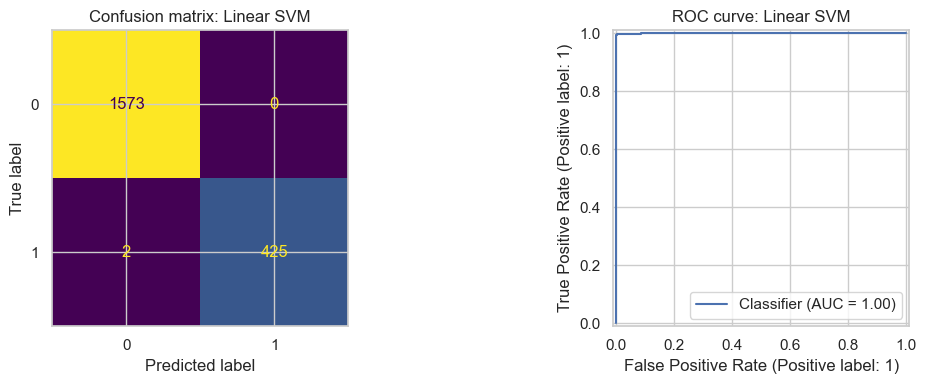

In [54]:
best_model_name = metrics.iloc[0]["model"]
best_model = trained_models[best_model_name]

y_pred = best_model.predict(X_test)
y_score = best_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f"Confusion matrix: {best_model_name}")
RocCurveDisplay.from_predictions(y_test, y_score, ax=axes[1])
axes[1].set_title(f"ROC curve: {best_model_name}")
plt.tight_layout()


## 7. Скоринг всех сообщений и временная динамика

Лучшей моделью оцениваем все сообщения и строим агрегированные графики без раскрытия реальных имён.


In [55]:
all_scores = best_model.predict_proba(messages[["text", *NUMERIC_FEATURES]])[:, 1]
scored_messages = messages[["message_hash", "chat", "date", "hour", "month", "user"]].copy()
scored_messages["toxicity_score"] = all_scores
scored_messages.head()


,message_hash,chat,date,hour,month,user,toxicity_score
265970,c50759f909ee5e87,kpp,2025-06-25 14:01:47,14,2025-06,user_004,1.000000e+00
252583,5435643c8d66f764,kpp,2025-06-03 17:21:56,17,2025-06,user_002,1.851230e-08
264322,6a368445aa549af7,kpp,2025-06-20 15:18:17,15,2025-06,user_001,8.759529e-07
165820,a0dd242b936d13fb,kpp,2025-01-10 15:54:24,15,2025-01,user_002,1.933914e-08
224171,bb8e1dbb16d94eac,kpp,2025-04-20 12:32:47,12,2025-04,user_002,2.627714e-08


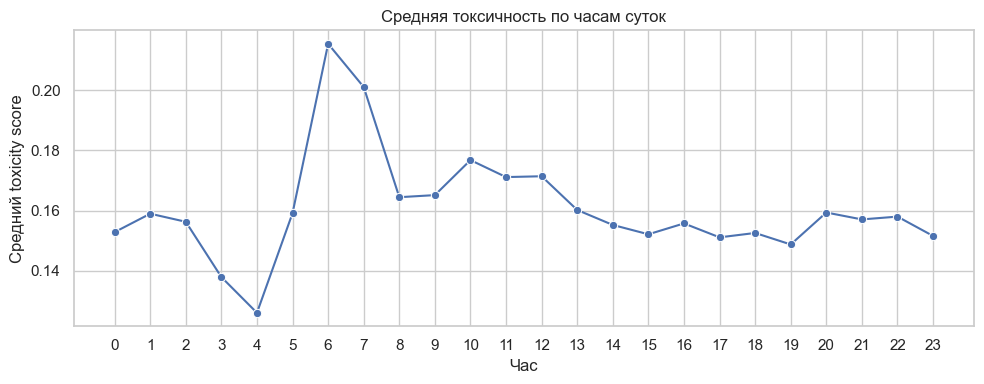

In [56]:
hourly = (
    scored_messages.dropna(subset=["hour"])
    .groupby("hour", as_index=False)
    .agg(mean_toxicity=("toxicity_score", "mean"), messages=("toxicity_score", "size"))
)

plt.figure(figsize=(10, 4))
sns.lineplot(data=hourly, x="hour", y="mean_toxicity", marker="o")
plt.title("Средняя токсичность по часам суток")
plt.xlabel("Час")
plt.ylabel("Средний toxicity score")
plt.xticks(range(0, 24))
plt.tight_layout()


,time_period,mean_toxicity,messages
1,other_time,0.158552,112119
0,evening_18_23,0.154739,87881


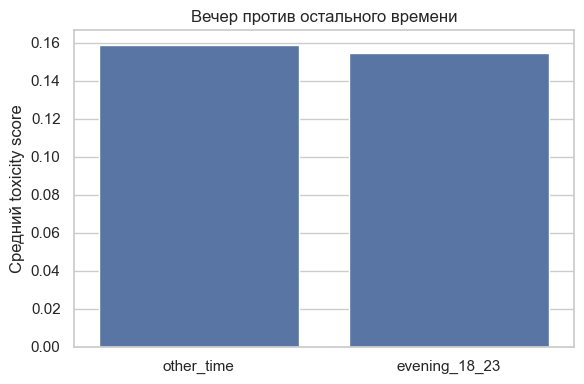

In [57]:
period = scored_messages.dropna(subset=["hour"]).copy()
period["time_period"] = np.where(period["hour"].between(18, 23), "evening_18_23", "other_time")

period_summary = (
    period.groupby("time_period", as_index=False)
    .agg(mean_toxicity=("toxicity_score", "mean"), messages=("toxicity_score", "size"))
    .sort_values("mean_toxicity", ascending=False)
)

plt.figure(figsize=(6, 4))
sns.barplot(data=period_summary, x="time_period", y="mean_toxicity")
plt.title("Вечер против остального времени")
plt.xlabel("")
plt.ylabel("Средний toxicity score")
plt.tight_layout()

period_summary


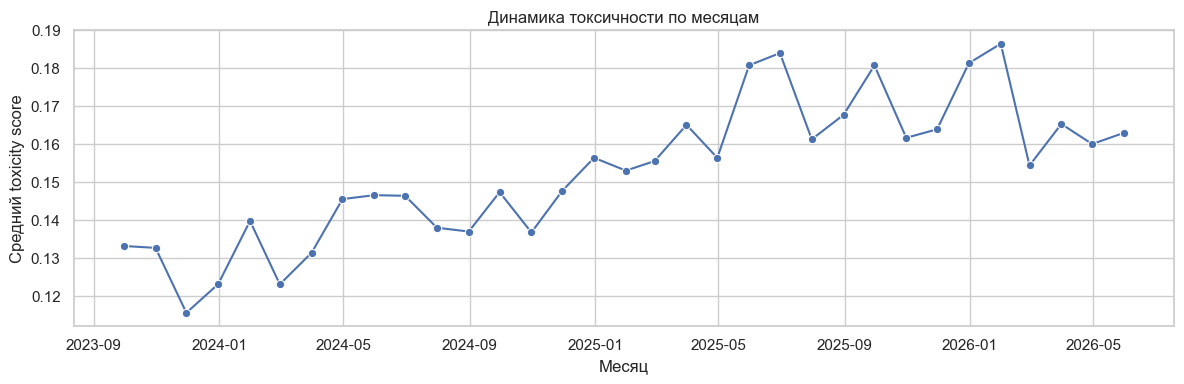

In [58]:
monthly = (
    scored_messages.dropna(subset=["date"])
    .set_index("date")
    .resample("ME")
    .agg(mean_toxicity=("toxicity_score", "mean"), messages=("toxicity_score", "size"))
    .reset_index()
)

plt.figure(figsize=(12, 4))
sns.lineplot(data=monthly, x="date", y="mean_toxicity", marker="o")
plt.title("Динамика токсичности по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Средний toxicity score")
plt.tight_layout()


,user,mean_toxicity,messages
0,user_001,0.193997,53444
1,user_004,0.165341,53682
2,user_003,0.155247,25497
3,user_002,0.121304,67377


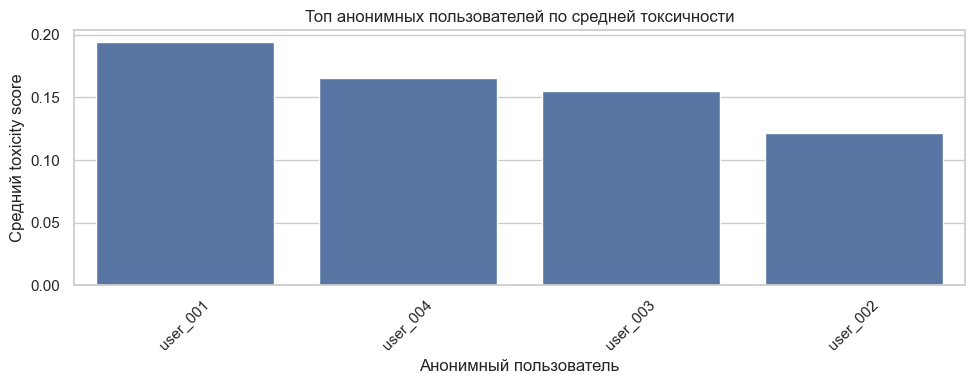

In [59]:
top_users = (
    scored_messages.groupby("user")
    .agg(mean_toxicity=("toxicity_score", "mean"), messages=("toxicity_score", "size"))
    .query("messages >= 100")
    .sort_values("mean_toxicity", ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10, 4))
sns.barplot(data=top_users, x="user", y="mean_toxicity")
plt.title("Топ анонимных пользователей по средней токсичности")
plt.xlabel("Анонимный пользователь")
plt.ylabel("Средний toxicity score")
plt.xticks(rotation=45)
plt.tight_layout()

top_users


## 8. Sanity checks

Эти проверки нужны, чтобы показать, что парсер и подготовка данных работают корректно.


In [60]:
assert telegram_text_to_str("abc") == "abc"
assert telegram_text_to_str(["a", {"type": "bold", "text": "b"}, "c"]) == "abc"
assert messages["text"].str.len().min() > 0
assert "raw_user_id" not in messages.columns
assert messages["user"].str.match(r"user_\d{3}").all()
assert set(labeled["toxic"].unique()).issubset({0, 1})
assert len(metrics) == 3

print("Все проверки пройдены.")


Все проверки пройдены.


## Краткий вывод для отчёта

В отчёт можно перенести:

- сколько сообщений осталось после фильтрации;
- размер ручной разметки и баланс классов;
- таблицу `metrics` с F1 и ROC-AUC;
- confusion matrix и ROC-кривую лучшей модели;
- графики токсичности по часам и месяцам.

Реальные тексты переписки в отчёт лучше не вставлять.
